In [4]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency
from statsmodels.stats.multicomp import pairwise_tukeyhsd

sys.path.append('./modules')
df = pd.read_csv('../data/01-interim/epcg23_interim_cleaned.csv', low_memory = False)

In [5]:
## Load EDA1 DF + Filter 
df_eda1 = df.copy()

label_map = {
    1: 'Computer/Math Science',
    2: 'Bio/Agricultural/Life Science',
    3: 'Physical & Related Science',
    4: 'Social & Related Science',
    5: 'Engineering',
    6: 'Science & Engineering Related',
    7: 'Non-Science & Engineering'
}

# Filter out Logical Skip and apply
df_eda1 = df_eda1[df_eda1['NBAMEMG'] < 8]
df_eda1 = df_eda1[df_eda1['N2OCPRMG'] < 8]
df_eda1['Major_Category'] = df_eda1['NBAMEMG'].map(label_map)
df_eda1['Job_Category'] = df_eda1['N2OCPRMG'].map(label_map)

In [7]:
## Load EDA3 + Map (load directly — needs unfiltered LFSTAT)
df_eda3 = pd.read_csv('../data/00-raw/epcg23.csv', low_memory=False)

# Apply same column selection as wrangling step
df_eda3 = df_eda3[['NBAMEMG', 'LFSTAT']].copy()
df_eda3['NBAMEMG'] = pd.to_numeric(df_eda3['NBAMEMG'], errors='coerce')
df_eda3['LFSTAT']  = pd.to_numeric(df_eda3['LFSTAT'],  errors='coerce')

df_eda3 = df_eda3[df_eda3['NBAMEMG'].notna() & df_eda3['LFSTAT'].notna()].copy()
df_eda3['NBAMEMG'] = df_eda3['NBAMEMG'].astype(int)  
df_eda3['LFSTAT']  = df_eda3['LFSTAT'].astype(int)

# Reuse label_map from EDA 1
df_eda3['Major_Category'] = df_eda3['NBAMEMG'].map(label_map)
df_eda3 = df_eda3[df_eda3['Major_Category'].notna()].copy()

## Map labor force status
labor_labels = {
    1: 'Employed',
    2: 'Unemployed',
    3: 'Not in Labor Force'
}
df_eda3['Labor_Status'] = df_eda3['LFSTAT'].map(labor_labels)

In [8]:
## Chi-Square Test
table_3 = pd.crosstab(
    df_eda3['Major_Category'], 
    df_eda3['Labor_Status']
)

# chi-square test
chi2, p, dof, expected = chi2_contingency(table_3)

print(f"Chi-square statistic: {chi2:.2f}")
print(f"P-value: {p:.4e}")
print(f"Degrees of freedom: {dof}")

Chi-square statistic: 794.39
P-value: 2.6356e-162
Degrees of freedom: 12


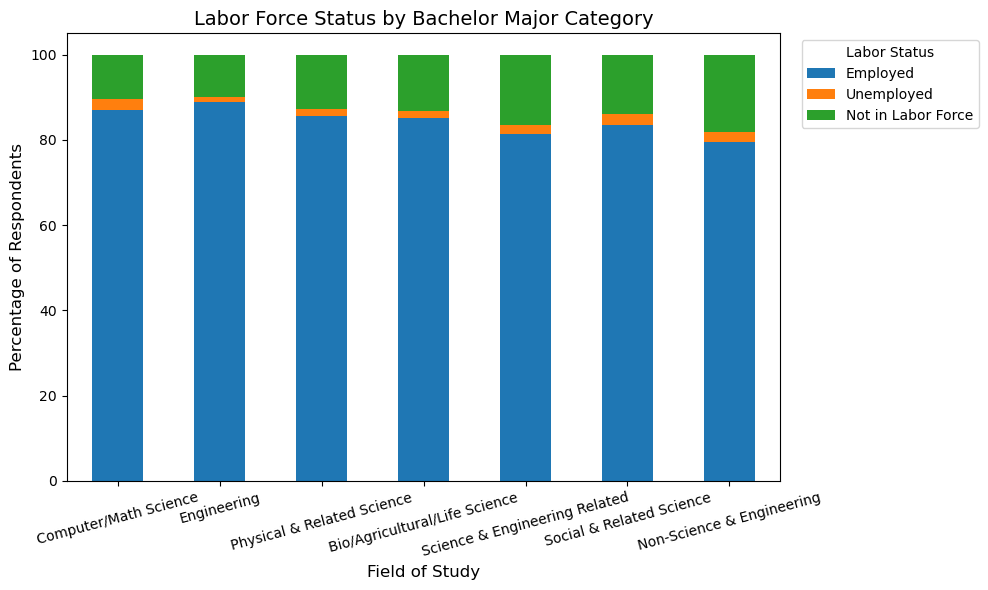

In [10]:
## EDA3 Plot:
## Stacked Bar Chart
table_pct = table_3.div(table_3.sum(axis=1), axis=0) * 100
table_pct = table_pct[['Employed', 'Unemployed', 'Not in Labor Force']]

major_order = [
    'Computer/Math Science',
    'Engineering',
    'Physical & Related Science',
    'Bio/Agricultural/Life Science',
    'Science & Engineering Related',
    'Social & Related Science',
    'Non-Science & Engineering'
]

table_pct = table_pct.reindex(major_order)

## plot
ax = table_pct.plot(
    kind='bar', 
    stacked=True, 
    figsize=(10, 6)
)

# formatting for plot 
plt.title('Labor Force Status by Bachelor Major Category', fontsize=14)
plt.xlabel('Field of Study', fontsize=12)
plt.ylabel('Percentage of Respondents', fontsize=12)
plt.xticks(rotation=15)
plt.legend(title='Labor Status', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()

os.makedirs('../results/EDA3_figs', exist_ok=True)
plt.savefig('../results/EDA3_figs/lbf-by-major.png', dpi=150, bbox_inches='tight')
plt.show()